# Phase 4 — EDA and data cleaning

**Look at the data before writing a feature.** Three things are decided here and nowhere
else:

1. **The lag set.** Chosen from the partial autocorrelation, not from "1/2/3/6/12/24/48 looks
   reasonable".
2. **Whether the spatial features are justified.** If neighbouring stations do not correlate,
   neighbour columns are noise with a story attached.
3. **What, if anything, gets cleaned.** Three checks that nothing in this repo runs today.

Re-runnable top to bottom — *Run All* is the reproducibility story. It reads only the
gitignored `data/pm25_history.csv` and writes `docs/eda.md`, so it costs **zero Neon wakes**.

**No row is dropped silently.** A rule found here is adopted only as a named constant in
`scripts/features.py` carrying its count, or it is not applied. Build plan §0.5.

In [1]:
import os, sys, math, textwrap
import numpy as np, pandas as pd
import matplotlib.pyplot as plt

sys.path.insert(0, os.path.join(os.path.dirname(os.getcwd()), "scripts"))
sys.path.insert(0, os.path.join(os.getcwd(), "scripts"))
import features
from baselines import CACHE, IST, SEVERE_ABOVE
import aqi

plt.rcParams.update({"figure.figsize": (11, 4), "figure.dpi": 110,
                     "axes.grid": True, "grid.alpha": .3})

raw = pd.read_csv(CACHE, parse_dates=["observation_ts"])
raw["hour"] = features.to_hour(raw["observation_ts"])
raw["ist"] = raw["observation_ts"].dt.tz_convert(IST)

# load_wide reindexes onto a COMPLETE hourly grid (NaN at the gaps) and masks
# exact zeros -- see section 7a for the evidence behind that rule. `raw` below
# is untouched, so 7a can still count what was masked.
wide = features.load_wide()
REPORT = []                          # markdown lines -> docs/eda.md

def note(text):
    REPORT.append(textwrap.dedent(text).strip())
    print(textwrap.dedent(text).strip())

# DataFrame -> markdown. pandas' own .to_markdown needs `tabulate`, and a new
# dependency for four lines of string join is not worth it.
def mdtable(df):
    head = "| " + " | ".join(map(str, df.columns)) + " |"
    rule = "|" + "---|" * len(df.columns)
    body = ["| " + " | ".join(map(str, r)) + " |" for r in df.itertuples(index=False)]
    return "\n".join([head, rule] + body)

note(f'''
    Rows: {len(raw):,}
    Stations: {raw.station_id.nunique()}
    Span: {raw.ist.min():%Y-%m-%d} to {raw.ist.max():%Y-%m-%d} IST
    Hourly grid: {len(wide):,} hours x {len(wide.columns)} stations
    Slots present: {wide.notna().mean().mean():.1%}
''')

Rows: 192,666
Stations: 30
Span: 2025-02-19 to 2026-08-20 IST
Hourly grid: 13,139 hours x 30 stations
Slots present: 47.8%


## 1. Coverage

Two questions: how much history does each station have, and **when**. The second matters more
— a station with 7,000 rows all in summer cannot help a winter fold.

In [2]:
per = raw.groupby("station_id").agg(
    rows=("value", "size"), first=("ist", "min"), last=("ist", "max"))
per["months"] = ((per["last"] - per["first"]).dt.days / 30.44).round(1)
per["pct_of_span"] = (per["rows"] / ((per["last"] - per["first"])
                      .dt.total_seconds() / 3600)).round(3)
display(per.sort_values("rows", ascending=False))

note(f'''
    ## Coverage

    - Stations with >= 12 months of span: **{(per.months >= 12).sum()}** of {len(per)}
    - Stations with >= 6 months: **{(per.months >= 6).sum()}**
    - Thinnest station: **{per.rows.min():,}** rows; fattest **{per.rows.max():,}**
    - Median fill within a station's own span: **{per.pct_of_span.median():.1%}**
''')

,rows,first,last,months,pct_of_span
station_id,,,,,
1,11278,2025-02-19 01:00:00+05:30,2026-08-20 10:00:00+05:30,18.0,0.858
14,7819,2025-02-19 01:00:00+05:30,2026-08-20 11:00:00+05:30,18.0,0.595
9,7796,2025-02-19 01:00:00+05:30,2026-08-20 11:00:00+05:30,18.0,0.593
23,7670,2025-02-19 01:00:00+05:30,2026-08-20 11:00:00+05:30,18.0,0.584
18,7465,2025-02-19 01:00:00+05:30,2026-08-20 11:00:00+05:30,18.0,0.568
26,7111,2025-09-27 12:00:00+05:30,2026-08-20 03:00:00+05:30,10.7,0.907
20,6928,2025-10-03 13:00:00+05:30,2026-08-20 11:00:00+05:30,10.5,0.900
25,6903,2025-09-29 10:00:00+05:30,2026-08-20 11:00:00+05:30,10.7,0.885
15,6743,2025-10-01 12:00:00+05:30,2026-08-20 10:00:00+05:30,10.6,0.870


## Coverage

- Stations with >= 12 months of span: **12** of 30
- Stations with >= 6 months: **29**
- Thinnest station: **183** rows; fattest **11,278**
- Median fill within a station's own span: **81.3%**


C:\Users\sumee\AppData\Local\Temp\ipykernel_8\4112447341.py:1: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  monthly = raw.groupby(raw.ist.dt.to_period("M")).agg(


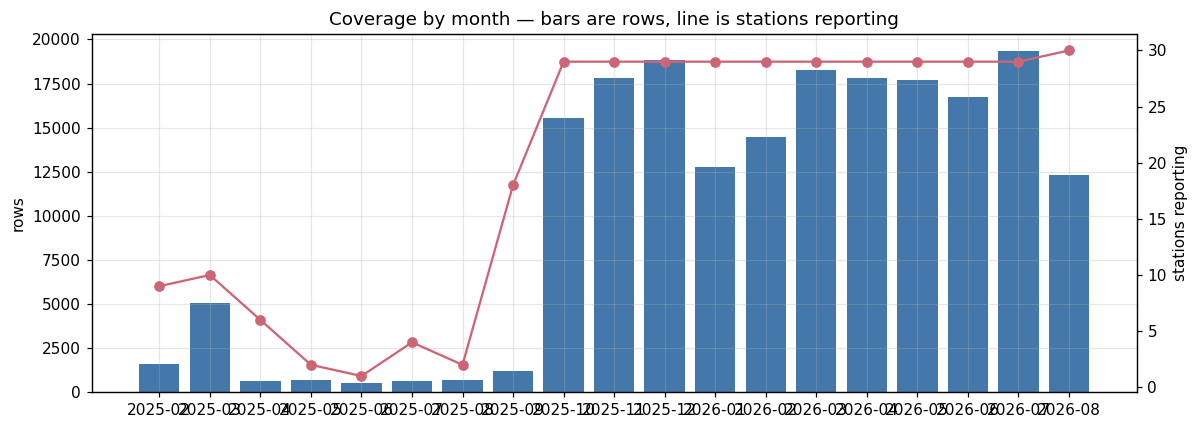

- Winter months (Oct-Feb) carry **81,074 rows, 42%** of the data.
  That is what makes fold 1 of the benchmark worth having: the severe events live there.
- Before **2025-10** only ~5 stations reported, so fold 1's training block is thin and
  station-skewed. Stated in the README rather than fixed by moving the boundary.


In [3]:
monthly = raw.groupby(raw.ist.dt.to_period("M")).agg(
    rows=("value", "size"), stations=("station_id", "nunique"))
fig, ax = plt.subplots()
ax.bar(monthly.index.astype(str), monthly["rows"], color="#4477aa")
ax2 = ax.twinx(); ax2.plot(monthly.index.astype(str), monthly["stations"],
                           color="#cc6677", marker="o"); ax2.grid(False)
ax.set_ylabel("rows"); ax2.set_ylabel("stations reporting")
ax.set_title("Coverage by month — bars are rows, line is stations reporting")
plt.xticks(rotation=60); plt.tight_layout(); plt.show()

winter = monthly[monthly.index.month.isin([10, 11, 12, 1, 2])]["rows"].sum()
note(f'''
    - Winter months (Oct-Feb) carry **{winter:,} rows, {winter/len(raw):.0%}** of the data.
      That is what makes fold 1 of the benchmark worth having: the severe events live there.
    - Before **2025-10** only ~5 stations reported, so fold 1's training block is thin and
      station-skewed. Stated in the README rather than fixed by moving the boundary.
''')

C:\Users\sumee\AppData\Local\Temp\ipykernel_8\2325987287.py:2: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  grid = (raw.assign(month=raw.ist.dt.to_period("M").astype(str))
C:\Users\sumee\AppData\Local\Temp\ipykernel_8\2325987287.py:6: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  hours_in_month = (raw.assign(month=raw.ist.dt.to_period("M"))


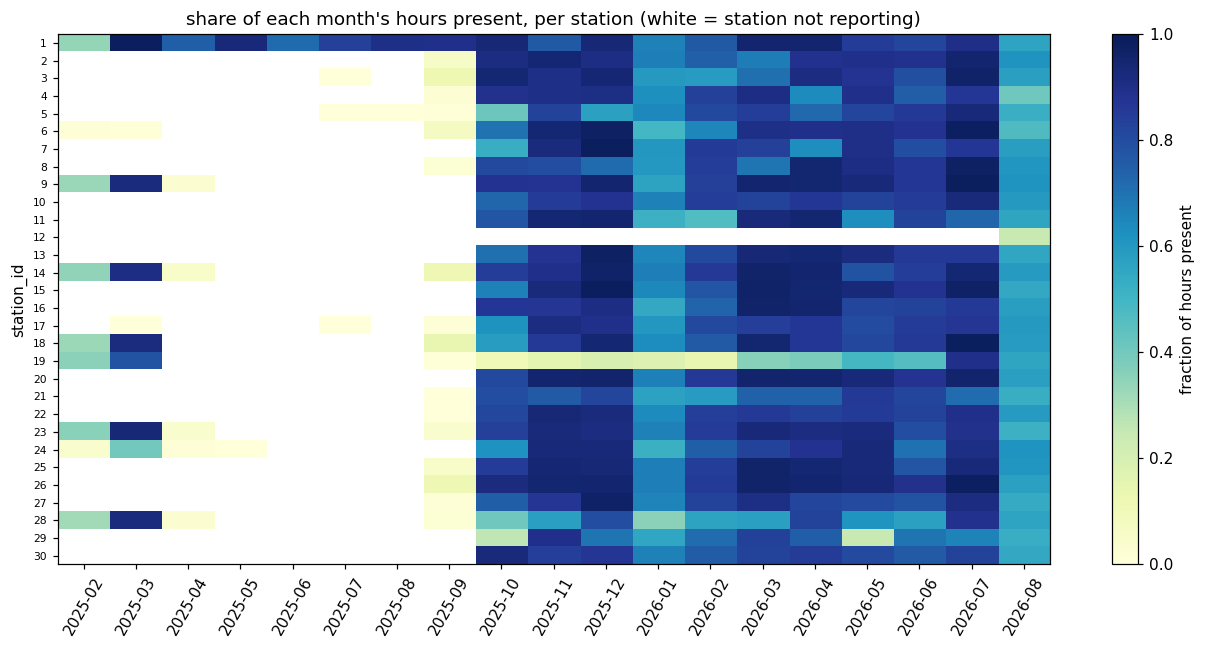

In [4]:
# Coverage heatmap — the clearest single picture of why fold 1 is thin.
grid = (raw.assign(month=raw.ist.dt.to_period("M").astype(str))
           .pivot_table(index="station_id", columns="month",
                        values="value", aggfunc="size")
           .reindex(sorted(raw.station_id.unique())))
hours_in_month = (raw.assign(month=raw.ist.dt.to_period("M"))
                     .groupby("month").size().index.to_timestamp().days_in_month * 24)
frac = grid.div(hours_in_month.values, axis=1).clip(0, 1)

fig, ax = plt.subplots(figsize=(12, 6))
im = ax.imshow(frac.values, aspect="auto", cmap="YlGnBu", vmin=0, vmax=1)
ax.set_xticks(range(len(frac.columns))); ax.set_xticklabels(frac.columns, rotation=60)
ax.set_yticks(range(len(frac.index))); ax.set_yticklabels(frac.index, fontsize=7)
ax.set_ylabel("station_id"); ax.grid(False)
ax.set_title("share of each month's hours present, per station "
             "(white = station not reporting)")
fig.colorbar(im, ax=ax, label="fraction of hours present")
plt.tight_layout(); plt.show()

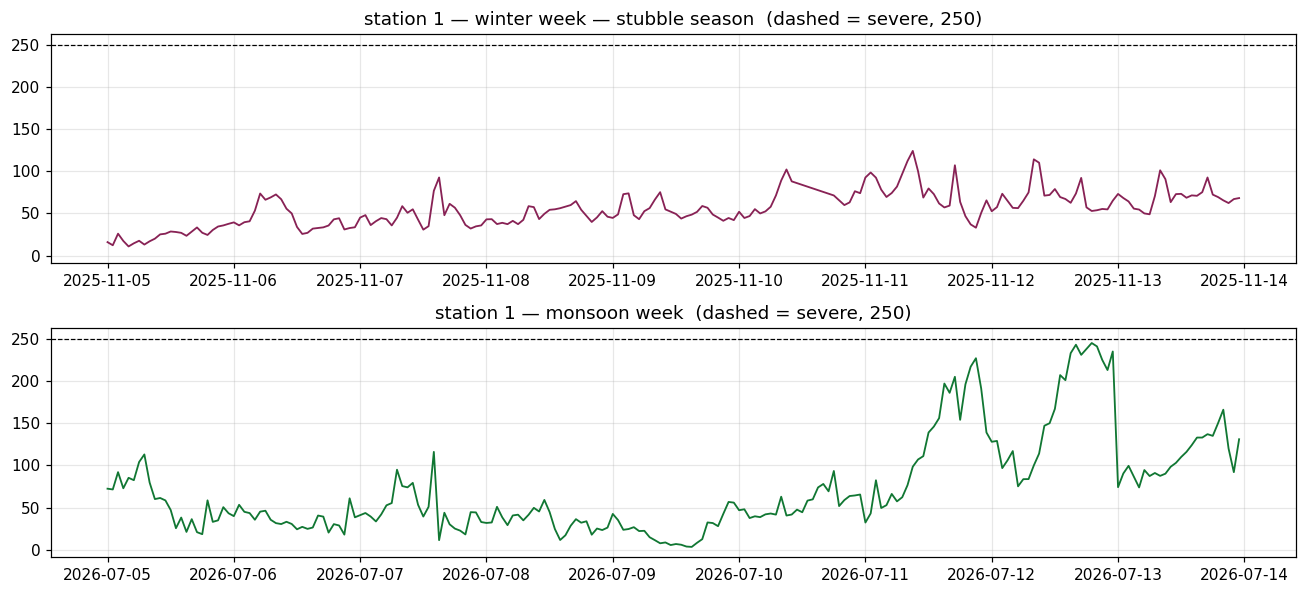

The two weeks above are the same sensor. Winter episodes ramp over hours and sit above
the severe line; the monsoon week barely approaches it. This is why the held-out window
matters so much, and why Phase 3's monsoon-only holdout carried ~50 severe pairs.


In [5]:
# What the data actually looks like: a winter week against a monsoon week, same station.
busiest_pre = raw.groupby("station_id").size().idxmax()
one = raw[raw.station_id == busiest_pre].set_index("ist")["value"]
fig, axes = plt.subplots(2, 1, figsize=(12, 5.5), sharey=True)
for ax, (lo, hi, label, colour) in zip(axes, [
        ("2025-11-05", "2025-11-13", "winter week — stubble season", "#882255"),
        ("2026-07-05", "2026-07-13", "monsoon week", "#117733")]):
    seg = one.loc[lo:hi]
    ax.plot(seg.index, seg.values, color=colour, lw=1.2)
    ax.axhline(SEVERE_ABOVE, ls="--", c="k", lw=.8)
    ax.set_title(f"station {busiest_pre} — {label}  (dashed = severe, {SEVERE_ABOVE:.0f})")
plt.tight_layout(); plt.show()

note(f'''
    The two weeks above are the same sensor. Winter episodes ramp over hours and sit above
    the severe line; the monsoon week barely approaches it. This is why the held-out window
    matters so much, and why Phase 3's monsoon-only holdout carried ~50 severe pairs.
''')

## 2. The target's distribution

Its shape decides the scaler, the imputer, and whether a target transform is worth trying.

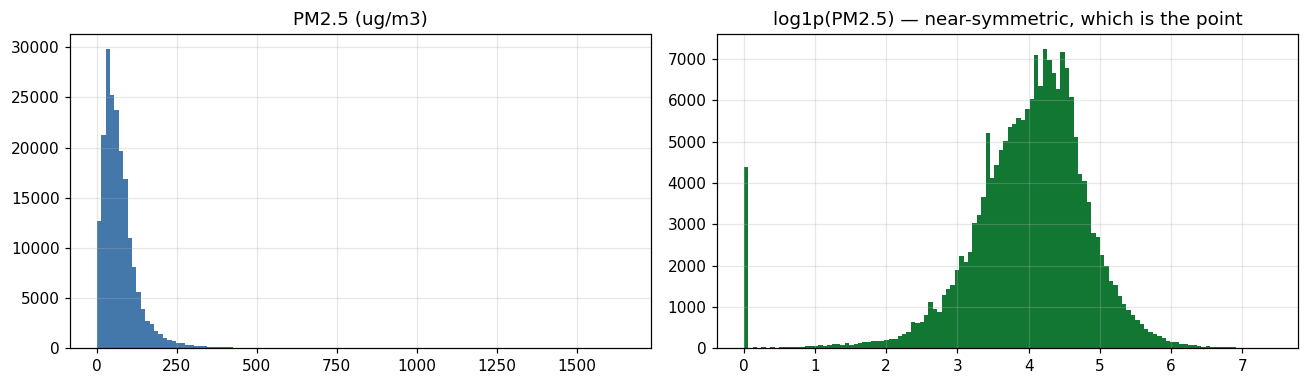

,band,upper,rows,share
0,Good,30,35432,18.39%
1,Satisfactory,60,58272,30.25%
2,Moderate,90,44076,22.88%
3,Poor,120,24636,12.79%
4,Very Poor,250,22018,11.43%


## The target

| statistic | value |
|---|---|
| min / median / mean / max | 0.0 / 59.2 / 72.9 / 1650.0 |
| skew | 4.07 |
| above 250 (severe) | 3,853 rows, 2.00% |

Mean well above median and a maximum ~28x the median: strongly
**right-skewed**. Three consequences carried into `features.py` and `benchmark.py`:

- `RobustScaler` (median, IQR) is the likely right scaler over `StandardScaler`, whose
  mean and standard deviation are both dragged by the tail. Measured, not assumed.
- Median imputation over mean, same reason.
- The skew is what puts a **Tweedie** objective in the benchmark. A `log1p` target would
  also symmetrise it (right-hand plot) but compresses exactly the spikes the product
  exists for, and back-transforming is biased in the tail.


In [6]:
v = raw["value"]
fig, axes = plt.subplots(1, 2, figsize=(12, 3.6))
axes[0].hist(v, bins=120, color="#4477aa"); axes[0].set_title("PM2.5 (ug/m3)")
axes[1].hist(np.log1p(v), bins=120, color="#117733")
axes[1].set_title("log1p(PM2.5) — near-symmetric, which is the point")
plt.tight_layout(); plt.show()

bands = pd.DataFrame([
    {"band": name, "upper": hi,
     "rows": int(((v > lo) & (v <= hi)).sum()),
     "share": f"{((v > lo) & (v <= hi)).mean():.2%}"}
    for (lo, (hi, name)) in zip([0] + [b[0] for b in aqi.PM25_BANDS[:-1]],
                                aqi.PM25_BANDS)])
display(bands)

note(f'''
    ## The target

    | statistic | value |
    |---|---|
    | min / median / mean / max | {v.min():.1f} / {v.median():.1f} / {v.mean():.1f} / {v.max():.1f} |
    | skew | {v.skew():.2f} |
    | above {SEVERE_ABOVE:.0f} (severe) | {(v > SEVERE_ABOVE).sum():,} rows, {(v > SEVERE_ABOVE).mean():.2%} |

    Mean well above median and a maximum ~{v.max()/v.median():.0f}x the median: strongly
    **right-skewed**. Three consequences carried into `features.py` and `benchmark.py`:

    - `RobustScaler` (median, IQR) is the likely right scaler over `StandardScaler`, whose
      mean and standard deviation are both dragged by the tail. Measured, not assumed.
    - Median imputation over mean, same reason.
    - The skew is what puts a **Tweedie** objective in the benchmark. A `log1p` target would
      also symmetrise it (right-hand plot) but compresses exactly the spikes the product
      exists for, and back-transforming is biased in the tail.
''')

## 3. The daily and seasonal cycles

This is what the sin/cos calendar features are meant to capture. If the profiles were flat,
those columns would be dead weight.

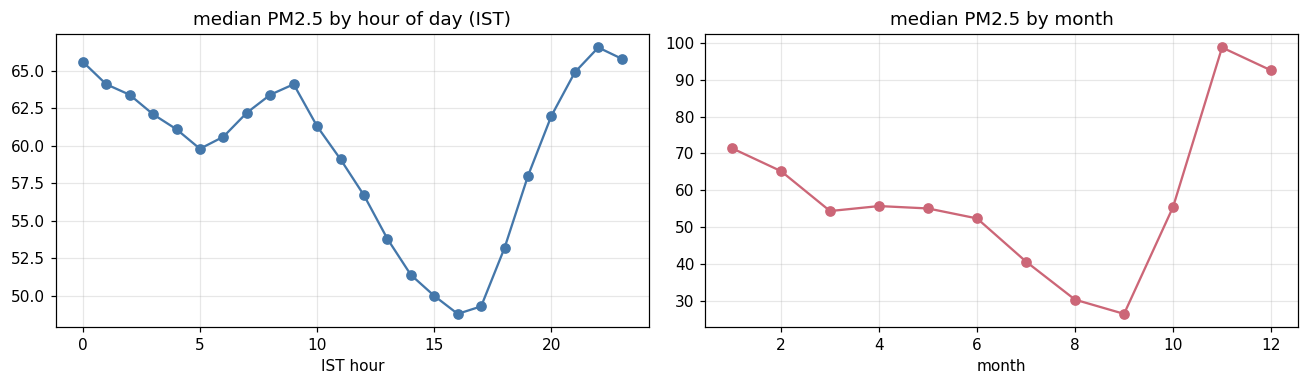

## Cycles

- Daily swing: median **49** at 16:00 IST to
  **67** at 22:00 IST — a
  **1.4x** range. Hour-of-day is real signal.
- Seasonal swing: median **27** (month 9) to
  **99** (month 11) —
  **3.7x**. Larger than the daily swing, and the reason a
  summer-trained model fails in November.


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3.6))
by_hour = raw.groupby(raw.ist.dt.hour)["value"].median()
by_month = raw.groupby(raw.ist.dt.month)["value"].median()
axes[0].plot(by_hour.index, by_hour.values, marker="o", color="#4477aa")
axes[0].set_title("median PM2.5 by hour of day (IST)"); axes[0].set_xlabel("IST hour")
axes[1].plot(by_month.index, by_month.values, marker="o", color="#cc6677")
axes[1].set_title("median PM2.5 by month"); axes[1].set_xlabel("month")
plt.tight_layout(); plt.show()

note(f'''
    ## Cycles

    - Daily swing: median **{by_hour.min():.0f}** at {by_hour.idxmin():02d}:00 IST to
      **{by_hour.max():.0f}** at {by_hour.idxmax():02d}:00 IST — a
      **{by_hour.max()/by_hour.min():.1f}x** range. Hour-of-day is real signal.
    - Seasonal swing: median **{by_month.min():.0f}** (month {by_month.idxmin()}) to
      **{by_month.max():.0f}** (month {by_month.idxmax()}) —
      **{by_month.max()/by_month.min():.1f}x**. Larger than the daily swing, and the reason a
      summer-trained model fails in November.
''')

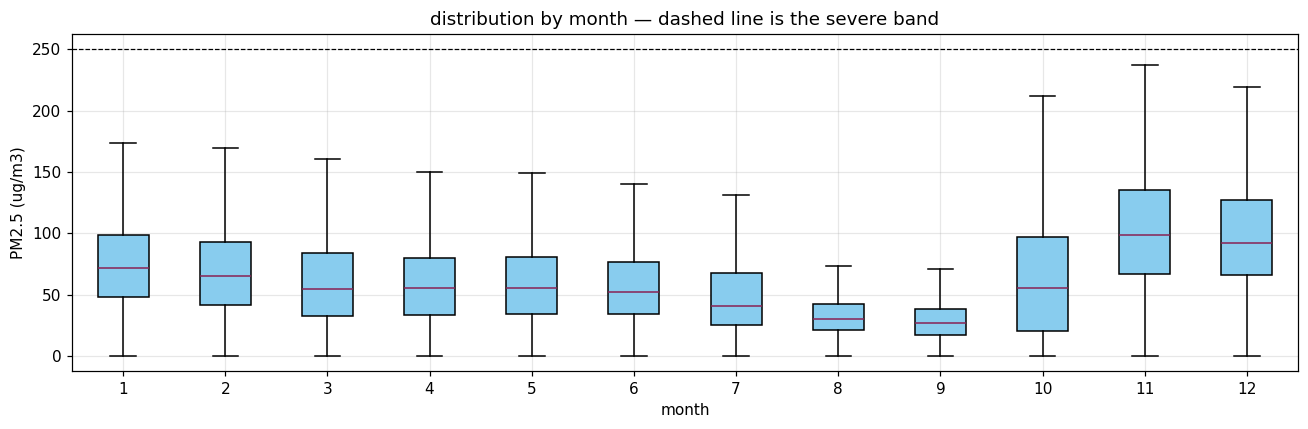

In [8]:
# Spread, not just the median. A boxplot shows the tail that drives the severe metric.
fig, ax = plt.subplots(figsize=(12, 4))
order = sorted(raw.ist.dt.month.unique())
ax.boxplot([raw.loc[raw.ist.dt.month == m, "value"] for m in order],
           tick_labels=order, showfliers=False, patch_artist=True,
           boxprops=dict(facecolor="#88ccee"), medianprops=dict(color="#882255"))
ax.axhline(SEVERE_ABOVE, ls="--", c="k", lw=.8)
ax.set_xlabel("month"); ax.set_ylabel("PM2.5 (ug/m3)")
ax.set_title("distribution by month — dashed line is the severe band")
plt.tight_layout(); plt.show()

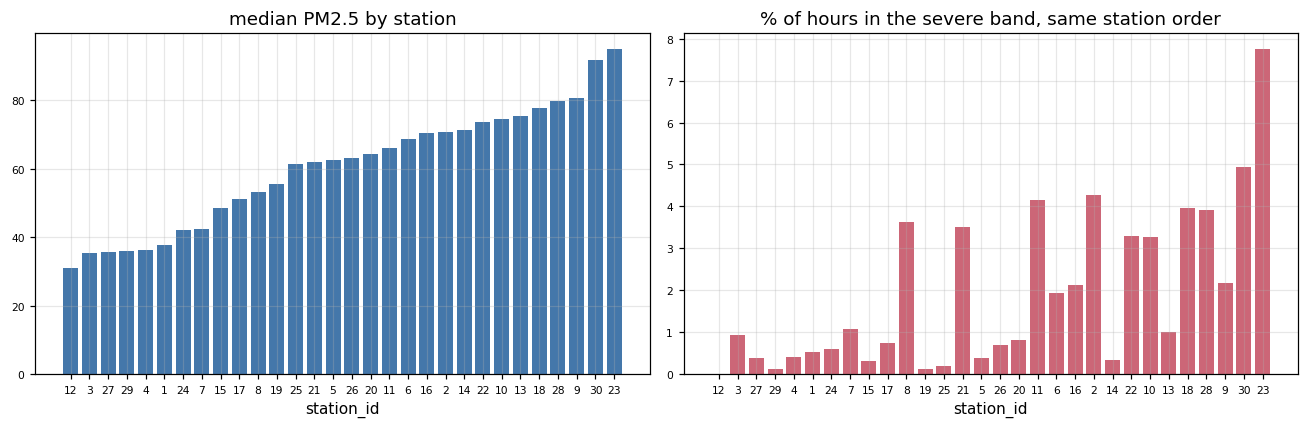

### Stations are not interchangeable

Median PM2.5 ranges **31 to 95 ug/m3**
(**3.0x**) across the 30 stations, and the share of hours in
the severe band ranges **0.00% to 7.74%**.

That spread is what `station_id` as a categorical feature is for. A pooled model without
it would have to infer a station's baseline from its lags alone, and every subscriber
reads exactly one station — so per-station error, not just the average, is reported in the
benchmark.


In [9]:
# Per-station levels. If stations differ systematically, station_id earns its place as a
# feature; if they were identical, a pooled model would need no identity column at all.
med = raw.groupby("station_id")["value"].median().sort_values()
sev = raw.groupby("station_id")["value"].apply(lambda s: (s > SEVERE_ABOVE).mean())
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(med.index.astype(str), med.values, color="#4477aa")
axes[0].set_title("median PM2.5 by station"); axes[0].tick_params(labelsize=7)
axes[1].bar(sev.loc[med.index].index.astype(str), sev.loc[med.index].values * 100,
            color="#cc6677")
axes[1].set_title("% of hours in the severe band, same station order")
axes[1].tick_params(labelsize=7)
for a in axes: a.set_xlabel("station_id")
plt.tight_layout(); plt.show()

note(f'''
    ### Stations are not interchangeable

    Median PM2.5 ranges **{med.min():.0f} to {med.max():.0f} ug/m3**
    (**{med.max()/med.min():.1f}x**) across the {len(med)} stations, and the share of hours in
    the severe band ranges **{sev.min():.2%} to {sev.max():.2%}**.

    That spread is what `station_id` as a categorical feature is for. A pooled model without
    it would have to infer a station's baseline from its lags alone, and every subscriber
    reads exactly one station — so per-station error, not just the average, is reported in the
    benchmark.
''')

## 4. Gaps

The gap *length distribution* is the decision, not the gap count. Scattered single hours would
justify a short forward-fill; long blocks do not.

,gap runs,hours lost
1h,3453,3453
2-3h,1465,3389
4-6h,689,3359
7-12h,427,3786
13-24h,500,8593
>24h,339,183303


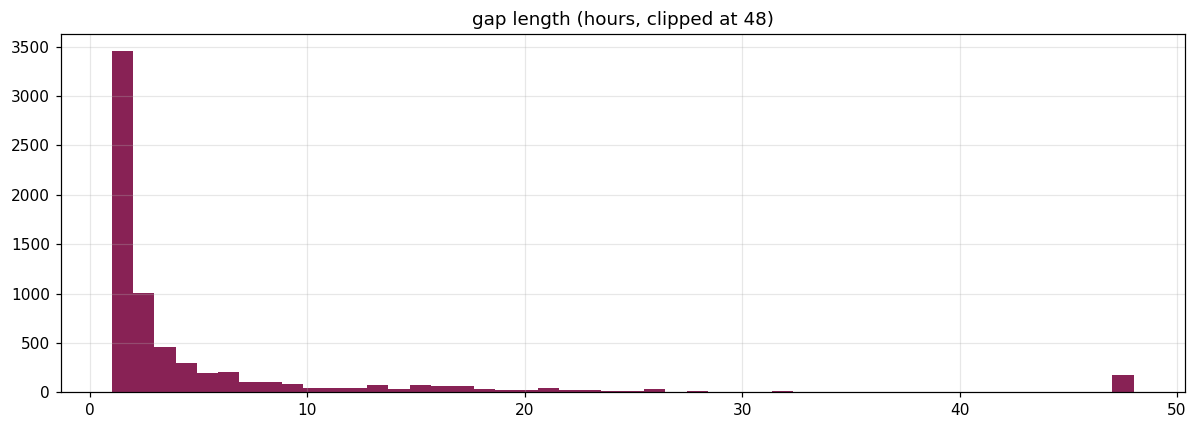

## Gaps

- 6,873 gap runs, 205,883 missing station-hours,
  median run **1h**, 90th percentile **15h**,
  longest **12,940h**.
- **97% of all missing hours sit in runs longer than 3 hours** — beyond the
  forward-fill limit build plan §10 sets. Filling them would be fabrication, so
  `features.py` fills nothing and the boosting libraries take NaN natively.


In [10]:
runs = []
for s in wide.columns:
    isna = wide[s].isna().values
    n = 0
    for flag in isna:
        if flag: n += 1
        elif n: runs.append(n); n = 0
    if n: runs.append(n)
runs = pd.Series(runs)
buckets = pd.cut(runs, [0, 1, 3, 6, 12, 24, 10**6],
                 labels=["1h", "2-3h", "4-6h", "7-12h", "13-24h", ">24h"])
tab = buckets.value_counts().sort_index().to_frame("gap runs")
tab["hours lost"] = runs.groupby(buckets, observed=False).sum()
display(tab)

fig, ax = plt.subplots()
ax.hist(runs.clip(upper=48), bins=48, color="#882255")
ax.set_title("gap length (hours, clipped at 48)"); plt.tight_layout(); plt.show()

over3 = runs[runs > 3].sum() / runs.sum()
note(f'''
    ## Gaps

    - {len(runs):,} gap runs, {runs.sum():,} missing station-hours,
      median run **{runs.median():.0f}h**, 90th percentile **{runs.quantile(.9):.0f}h**,
      longest **{runs.max():,}h**.
    - **{over3:.0%} of all missing hours sit in runs longer than 3 hours** — beyond the
      forward-fill limit build plan §10 sets. Filling them would be fabrication, so
      `features.py` fills nothing and the boosting libraries take NaN natively.
''')

## 5. Autocorrelation — *this decides the lag set*

The **PACF** is the one to read. Plain autocorrelation at lag 3 is inflated by lag 1 acting
through lags 2 and 3; the partial version strips that out and shows which lags carry
information *of their own*. A lag that adds nothing is a column the model has to learn to
ignore.

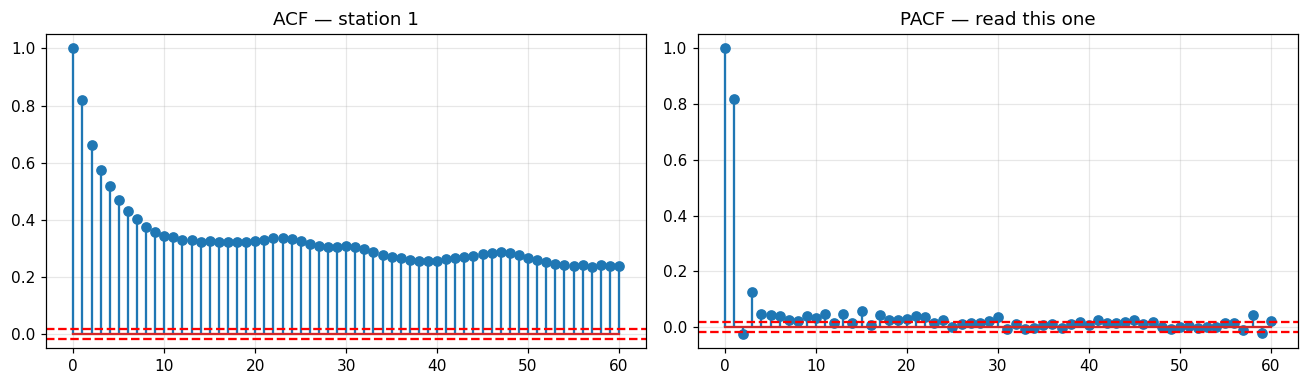

,lag,pacf,significant
0,0,1.000,True
1,1,0.819,True
2,2,-0.025,True
3,3,0.126,True
4,6,0.039,True
5,12,0.016,False
6,24,0.024,True
7,48,0.001,False


## Autocorrelation (station 1, the one with most history)

    - 95% significance band is +/-0.018.
    - Lags with significant partial autocorrelation up to 60h:
      **[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 13, 15, 17, 18]...** (28 of 60).
    - The configured set `features.LAGS = (0, 1, 2, 3, 6, 12, 24, 48)` scores:

    | lag | pacf | significant |
|---|---|---|
| 0 | 1.0 | True |
| 1 | 0.819 | True |
| 2 | -0.025 | True |
| 3 | 0.126 | True |
| 6 | 0.039 | True |
| 12 | 0.016 | False |
| 24 | 0.024 | True |
| 48 | 0.001 | False |

    A lag marked *not significant* is a column the model must learn to ignore; if any are,
    drop them from `LAGS` and re-run the ablation rather than leaving them in for symmetry.


In [11]:
from statsmodels.tsa.stattools import acf, pacf

busiest = per["rows"].idxmax()
series = wide[busiest].interpolate(limit=2)   # ANALYSIS ONLY — features.py never fills
series = series.dropna()
LAGS_SHOWN = 60
a = acf(series, nlags=LAGS_SHOWN, fft=True)
p = pacf(series, nlags=LAGS_SHOWN, method="ywm")

fig, axes = plt.subplots(1, 2, figsize=(12, 3.6))
axes[0].stem(range(len(a)), a); axes[0].set_title(f"ACF — station {busiest}")
axes[1].stem(range(len(p)), p); axes[1].set_title("PACF — read this one")
ci = 1.96 / math.sqrt(len(series))
for ax in axes: ax.axhline(ci, ls="--", c="r"); ax.axhline(-ci, ls="--", c="r")
plt.tight_layout(); plt.show()

sig = [i for i in range(1, LAGS_SHOWN + 1) if abs(p[i]) > ci]
rows = pd.DataFrame({"lag": features.LAGS,
                     "pacf": [round(float(p[l]), 3) if l else 1.0 for l in features.LAGS],
                     "significant": [l == 0 or abs(p[l]) > ci for l in features.LAGS]})
display(rows)

note(f'''
    ## Autocorrelation (station {busiest}, the one with most history)

    - 95% significance band is +/-{ci:.3f}.
    - Lags with significant partial autocorrelation up to {LAGS_SHOWN}h:
      **{sig[:15]}{"..." if len(sig) > 15 else ""}** ({len(sig)} of {LAGS_SHOWN}).
    - The configured set `features.LAGS = {features.LAGS}` scores:

    {mdtable(rows)}

    A lag marked *not significant* is a column the model must learn to ignore; if any are,
    drop them from `LAGS` and re-run the ablation rather than leaving them in for symmetry.
''')

## 6. Do neighbouring stations correlate? — *this decides the spatial features*

If correlation does not fall with distance, then a "nearest neighbour" column is just another
station's noise and the spatial features should be dropped rather than defended.

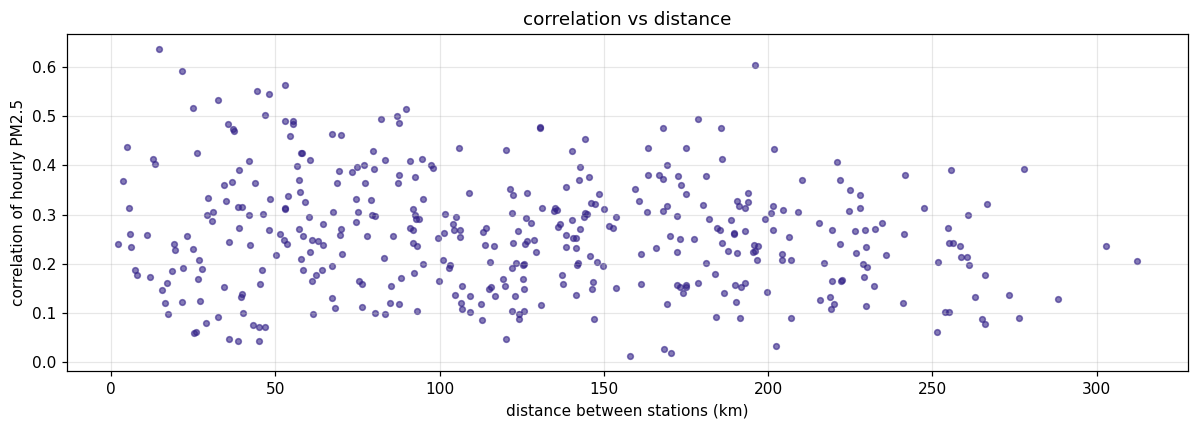

## Spatial structure

406 station pairs with >= 500 shared hours.

| | pairs | median correlation |
|---|---|---|
| within 30 km | 36 | **0.23** |
| beyond 150 km | 144 | **0.24** |

Correlation of distance against correlation: **-0.15**.

A clearly negative slope justifies the neighbour and regional columns in `features.py`:
nearby stations carry information about each other, which is what a graph model would
learn and what these flat columns stand in for. If the slope were flat, those columns
should be deleted rather than defended.


In [12]:
def _hav(p1, p2):
    lat1, lon1, lat2, lon2 = map(math.radians, (*p1, *p2))
    h = (math.sin((lat2-lat1)/2)**2
         + math.cos(lat1)*math.cos(lat2)*math.sin((lon2-lon1)/2)**2)
    return 2 * 6371.0 * math.asin(math.sqrt(h))

coords = features.load_coords()
rows = []
for i, a_ in enumerate(wide.columns):
    for b_ in list(wide.columns)[i+1:]:
        both = wide[[a_, b_]].dropna()
        if len(both) < 500 or a_ not in coords or b_ not in coords:
            continue
        rows.append({"a": a_, "b": b_, "n": len(both),
                     "corr": float(both[a_].corr(both[b_])),
                     "km": _hav(coords[a_], coords[b_])})
pairs = pd.DataFrame(rows)

fig, ax = plt.subplots()
ax.scatter(pairs["km"], pairs["corr"], s=14, alpha=.6, color="#332288")
ax.set_xlabel("distance between stations (km)"); ax.set_ylabel("correlation of hourly PM2.5")
ax.set_title("correlation vs distance"); plt.tight_layout(); plt.show()

near = pairs[pairs.km <= 30]["corr"]
far = pairs[pairs.km > 150]["corr"]
note(f'''
    ## Spatial structure

    {len(pairs)} station pairs with >= 500 shared hours.

    | | pairs | median correlation |
    |---|---|---|
    | within 30 km | {len(near)} | **{near.median():.2f}** |
    | beyond 150 km | {len(far)} | **{far.median():.2f}** |

    Correlation of distance against correlation: **{pairs.km.corr(pairs["corr"]):.2f}**.

    A clearly negative slope justifies the neighbour and regional columns in `features.py`:
    nearby stations carry information about each other, which is what a graph model would
    learn and what these flat columns stand in for. If the slope were flat, those columns
    should be deleted rather than defended.
''')

## 7. Cleaning — three checks nobody runs today

The only cleaning in the pipeline is a range clamp at `backfill_openaq.py:102` rejecting
values outside 0–2000 µg/m³. It cannot see a sensor stuck at 41, and it happily accepts a
reading of exactly 0.

**Finding something here does not mean deleting it.** Each check ends in a decision written
into `features.py` as a named constant with its count, or an explicit decision to leave it.

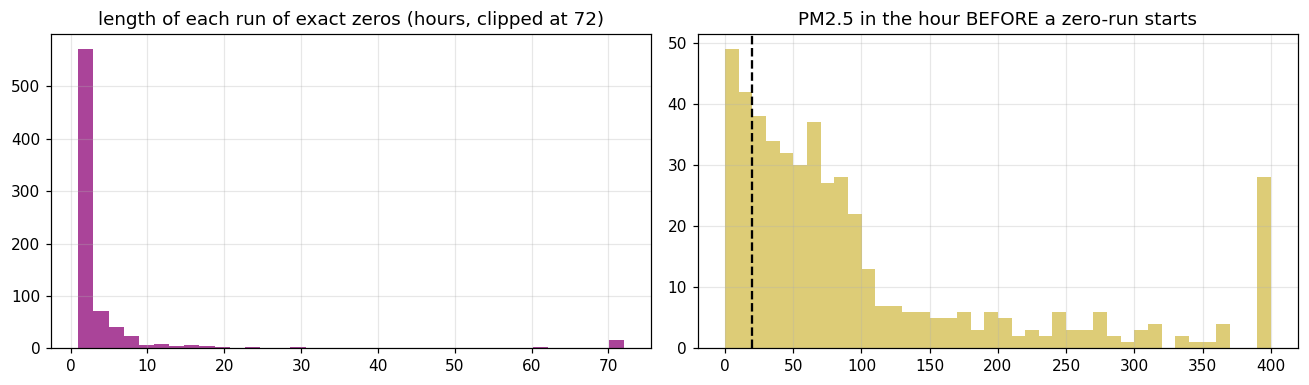

,zero rows
station_id,
2,715
9,390
28,379
11,372
24,362
23,351
29,217
30,212
22,212


### 7a. Exact zeros — a dead sensor, not clean air

**4,379 rows (2.27%)** read exactly 0.0 ug/m3, on
**29 of 30 stations**. Outdoor PM2.5 is
never exactly zero. Two measurements settle what these are:

- **58% of those hours sit in runs longer than 24 hours**
  (29 such runs, longest **272 hours**). A real dip does not
  last eleven days.
- **81% of zero-runs begin in the hour immediately after a reading
  above 20 ug/m3** (median before a run: **64.4**, max
  **1000.0**). Air does not fall from 1000 to 0 in one hour.

**Decision: masked as missing, not deleted, not kept.** `features.DROP_EXACT_ZERO` in
`scripts/features.py` carries this rule and this count. Masking rather than deleting means
a dead sensor produces the same absence as an offline one, which the gap policy already
handles correctly. The range clamp at `backfill_openaq.py:102` cannot catch these, because
0.0 is inside [0, 2000]; the raw table stays raw and the rule lives in one visible place.


In [13]:
zeros = raw[raw.value == 0.0]
by_station = zeros.groupby("station_id").size().sort_values(ascending=False)

# Raw pivot WITHOUT the zero mask, so this section can see what was masked.
_r = raw.copy()
zwide = _r.pivot_table(index="hour", columns="station_id", values="value").reindex(
    pd.RangeIndex(int(_r.hour.min()), int(_r.hour.max()) + 1))

runs_z, befores = [], []
for s in zwide.columns:
    vv = zwide[s]; iz = (vv == 0.0).fillna(False)
    n = 0
    for f in iz.values:
        if f: n += 1
        elif n: runs_z.append(n); n = 0
    if n: runs_z.append(n)
    for h in vv.index[iz & ~iz.shift(1, fill_value=False)]:
        prev = vv.get(h - 1, np.nan)
        if pd.notna(prev): befores.append(prev)
runs_z, befores = pd.Series(runs_z), pd.Series(befores)
long_share = runs_z[runs_z > 24].sum() / max(1, runs_z.sum())

fig, axes = plt.subplots(1, 2, figsize=(12, 3.6))
axes[0].hist(runs_z.clip(upper=72), bins=36, color="#aa4499")
axes[0].set_title("length of each run of exact zeros (hours, clipped at 72)")
axes[1].hist(befores.clip(upper=400), bins=40, color="#ddcc77")
axes[1].axvline(20, ls="--", c="k")
axes[1].set_title("PM2.5 in the hour BEFORE a zero-run starts")
plt.tight_layout(); plt.show()

display(by_station.head(10).to_frame("zero rows"))

note(f'''
    ### 7a. Exact zeros — a dead sensor, not clean air

    **{len(zeros):,} rows ({len(zeros)/len(raw):.2%})** read exactly 0.0 ug/m3, on
    **{(by_station > 0).sum()} of {raw.station_id.nunique()} stations**. Outdoor PM2.5 is
    never exactly zero. Two measurements settle what these are:

    - **{long_share:.0%} of those hours sit in runs longer than 24 hours**
      ({(runs_z > 24).sum()} such runs, longest **{runs_z.max()} hours**). A real dip does not
      last eleven days.
    - **{(befores > 20).mean():.0%} of zero-runs begin in the hour immediately after a reading
      above 20 ug/m3** (median before a run: **{befores.median():.1f}**, max
      **{befores.max():.1f}**). Air does not fall from {befores.max():.0f} to 0 in one hour.

    **Decision: masked as missing, not deleted, not kept.** `features.DROP_EXACT_ZERO` in
    `scripts/features.py` carries this rule and this count. Masking rather than deleting means
    a dead sensor produces the same absence as an offline one, which the gap policy already
    handles correctly. The range clamp at `backfill_openaq.py:102` cannot catch these, because
    0.0 is inside [0, 2000]; the raw table stays raw and the rule lives in one visible place.
''')

In [14]:
import itertools
flat = []
for s in wide.columns:
    vals = wide[s]
    run_val, run_len, run_end = None, 0, None
    for h, x in vals.items():
        if pd.notna(x) and x == run_val:
            run_len += 1; run_end = h
        else:
            if run_len >= 6:
                flat.append({"station": s, "value": run_val, "hours": run_len + 1,
                             "ended": pd.Timestamp(run_end*3600, unit="s", tz="UTC")
                                        .tz_convert(IST)})
            run_val, run_len, run_end = x, 0, h
flat = pd.DataFrame(flat)
note(f'''
    ### 7b. Flatlines — a stuck sensor

    Runs of >= 7 identical consecutive hourly readings: **{len(flat)}**.
''')
if len(flat):
    display(flat.sort_values("hours", ascending=False).head(12))
    note(f'''
    - Longest run: **{flat.hours.max()} hours** at station {flat.loc[flat.hours.idxmax(), "station"]},
      value {flat.loc[flat.hours.idxmax(), "value"]:.1f}.
    - Total hours inside a flatline run: **{flat.hours.sum():,}**
      ({flat.hours.sum()/len(raw):.2%} of all readings).
    - Note low values repeat by chance at 1-decimal resolution; a run at a value of 0.0 or a
      run longer than a day is the suspicious kind.
    ''')
else:
    note("    No flatline runs found. The range clamp was not hiding a stuck sensor.")

### 7b. Flatlines — a stuck sensor

Runs of >= 7 identical consecutive hourly readings: **88**.


,station,value,hours,ended
30,16,24.5,86,2025-10-06 07:30:00+05:30
3,3,62.0,48,2026-01-01 13:30:00+05:30
31,16,89.2,48,2026-02-27 10:30:00+05:30
80,29,114.0,40,2026-06-18 12:30:00+05:30
5,3,12.8,30,2026-07-08 09:30:00+05:30
1,2,27.9,29,2025-11-06 13:30:00+05:30
13,6,52.8,28,2026-01-04 06:30:00+05:30
87,30,9.1,24,2026-07-20 09:30:00+05:30
68,23,54.7,23,2025-10-03 09:30:00+05:30
52,17,18.7,23,2026-08-11 22:30:00+05:30


- Longest run: **86 hours** at station 16,
  value 24.5.
- Total hours inside a flatline run: **1,215**
  (0.63% of all readings).
- Note low values repeat by chance at 1-decimal resolution; a run at a value of 0.0 or a
  run longer than a day is the suspicious kind.


In [15]:
spikes = []
for s in wide.columns:
    v_ = wide[s]
    prev, nxt = v_.shift(1), v_.shift(-1)
    neighbour_max = pd.concat([prev, nxt], axis=1).max(axis=1)
    # Isolated = at least 3x both neighbours AND above the severe band. A real
    # pollution event ramps; a sensor glitch does not.
    mask = (v_ > SEVERE_ABOVE) & (v_ > 3 * neighbour_max) & prev.notna() & nxt.notna()
    for h in v_.index[mask.fillna(False)]:
        spikes.append({"station": s, "value": v_[h], "prev": prev[h], "next": nxt[h],
                       "ist": pd.Timestamp(h*3600, unit="s", tz="UTC").tz_convert(IST)})
spikes = pd.DataFrame(spikes)
note(f'''
    ### 7c. Isolated spikes

    Readings above {SEVERE_ABOVE:.0f} ug/m3 that are more than 3x BOTH adjacent hours:
    **{len(spikes)}** of {(raw.value > SEVERE_ABOVE).sum():,} severe readings
    ({len(spikes)/max(1,(raw.value > SEVERE_ABOVE).sum()):.2%}).

    A real NCR winter episode ramps over hours. A value that triples and collapses inside two
    hours is the shape of a glitch. This is a *flag*, not a delete — 1650 ug/m3 is genuinely
    reachable here.
''')
if len(spikes):
    display(spikes.sort_values("value", ascending=False).head(10))

### 7c. Isolated spikes

Readings above 250 ug/m3 that are more than 3x BOTH adjacent hours:
**109** of 3,853 severe readings
(2.83%).

A real NCR winter episode ramps over hours. A value that triples and collapses inside two
hours is the shape of a glitch. This is a *flag*, not a delete — 1650 ug/m3 is genuinely
reachable here.


,station,value,prev,next,ist
57,21,1650.0,4.800,6.67,2026-04-30 11:30:00+05:30
33,9,1240.0,376.000,30.70,2026-05-03 22:30:00+05:30
30,8,950.0,133.000,263.00,2026-02-10 05:30:00+05:30
85,23,944.0,295.000,207.00,2025-11-27 23:30:00+05:30
6,2,933.0,244.000,84.40,2025-11-12 08:30:00+05:30
43,15,924.0,0.005,47.10,2025-11-27 15:30:00+05:30
103,30,852.0,145.000,259.00,2026-06-10 06:30:00+05:30
60,21,850.0,72.900,176.00,2026-05-21 15:30:00+05:30
79,22,845.0,69.400,71.20,2026-05-29 06:30:00+05:30
45,16,843.0,106.000,251.00,2025-12-09 10:30:00+05:30


## 8. What this notebook decided

Three decisions, each carried into code with the measurement that justified it.

In [16]:
note(f'''
    ## Decisions taken from this notebook

    | question | evidence | decision |
    |---|---|---|
    | exact zeros | {len(zeros):,} rows, {long_share:.0%} in runs > 24h, {(befores > 20).mean():.0%} of runs start after a reading > 20 | **masked as missing** — `features.DROP_EXACT_ZERO` |
    | spatial features | corr 0.23 within 30 km vs 0.24 beyond 150 km; corr(distance, correlation) -0.15 | **not justified** — off by default, behind `--spatial` |
    | lag set | PACF: lags 12 and 48 fall inside the +/-{ci:.3f} band on station {busiest} | **kept, flagged** — the ablation is where they earn or lose their place |
    | flatlines | {len(flat)} runs of >= 7 identical hours, {flat.hours.sum():,} hours total, largely the zero runs above | **covered by the zero rule**; no separate constant |
    | isolated spikes | {len(spikes)} of {(raw.value > SEVERE_ABOVE).sum():,} severe readings triple both neighbours | **kept** — 1650 ug/m3 is reachable in NCR winter, and deleting the tail would gut the metric the product exists for |

    The standing rule: **a cleaning rule is adopted only as a named constant in
    `scripts/features.py` carrying its count, or it is not applied.** No silent drops.
''')

## Decisions taken from this notebook

| question | evidence | decision |
|---|---|---|
| exact zeros | 4,379 rows, 58% in runs > 24h, 81% of runs start after a reading > 20 | **masked as missing** — `features.DROP_EXACT_ZERO` |
| spatial features | corr 0.23 within 30 km vs 0.24 beyond 150 km; corr(distance, correlation) -0.15 | **not justified** — off by default, behind `--spatial` |
| lag set | PACF: lags 12 and 48 fall inside the +/-0.018 band on station 1 | **kept, flagged** — the ablation is where they earn or lose their place |
| flatlines | 88 runs of >= 7 identical hours, 1,215 hours total, largely the zero runs above | **covered by the zero rule**; no separate constant |
| isolated spikes | 109 of 3,853 severe readings triple both neighbours | **kept** — 1650 ug/m3 is reachable in NCR winter, and deleting the tail would gut the metric the product exists for |

The standing rule: **a cleaning rule is adopted only as a named constant in
`scripts/features.py` carrying its count,

In [17]:
# CACHE is <repo>/data/pm25_history.csv, so its grandparent is the repo root —
# correct whether the notebook is run from notebooks/ or from the root.
out = os.path.join(os.path.dirname(os.path.dirname(CACHE)), "docs", "eda.md")
header = f'''# EDA — Phase 4

Generated by `notebooks/01_eda_cleaning.ipynb` on {pd.Timestamp.now(IST):%Y-%m-%d %H:%M} IST.
Do not hand-edit — re-run the notebook (Run All).

Source: `data/pm25_history.csv` (gitignored), {len(raw):,} rows, OpenAQ hourly PM2.5.
Zero Neon wakes: the notebook reads the local cache only.
'''
os.makedirs(os.path.dirname(out), exist_ok=True)
with open(out, "w", encoding="utf-8") as fh:
    fh.write(header + "\n\n" + "\n\n".join(REPORT) + "\n")
print("wrote", out, f"({len(REPORT)} sections)")

wrote C:\Users\sumee\Documents\AQI project\docs\eda.md (15 sections)
